In [1]:
from numba.core.interpreter import peep_hole_list_to_tuple
from utils.plot_utils import plot_results
from battery_sizing_cfa.optimizers.peak_shaver import optimize_peak_shaving
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from battery_sizing_cfa.utils.fun_utils import rolling_inverted_quantile
data = pd.read_pickle("datasets/portugal/portugal.pk")


Set parameter Username
Set parameter LicenseID to value 2728923
Academic license - for non-commercial use only - expires 2026-10-28


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1254
[LightGBM] [Info] Number of data points in the train set: 7200, number of used features: 5
[LightGBM] [Info] Start training from score 0.058174
Objective : 3.40e+02


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1254
[LightGBM] [Info] Number of data points in the train set: 7200, number of used features: 5
[LightGBM] [Info] Start training from score 15.671209


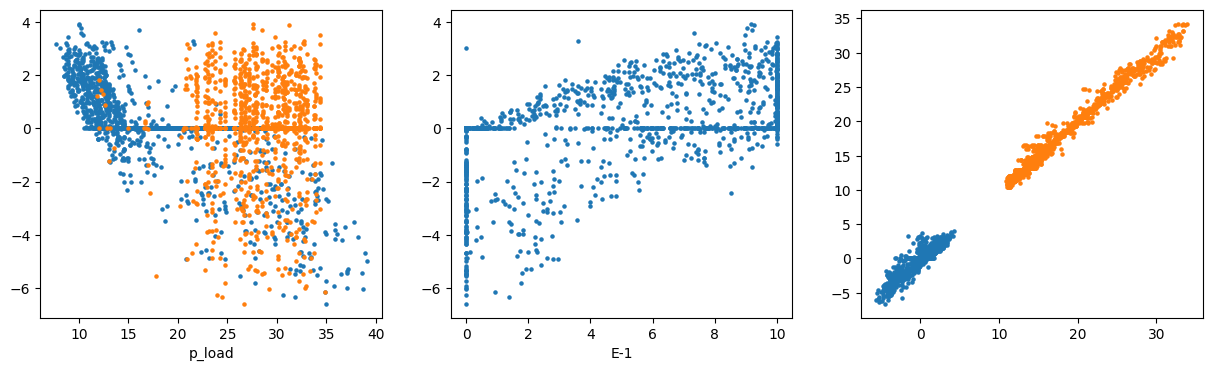

In [2]:
import plotly.graph_objects as go

specs = {'c_bat_E_kwh': 10.0,
         'energy_ratio': 2.0,
         'eta_ch': 0.95,
         'eta_dis': 0.95,
         'soc_min':0,
         'soc_max':1,
         'soc_start':0.5}

# plot results in terms of battery power and SOC
n_tr = 300*24  # Use a multiple of 24 for full days
n_te = 60*24
for i in [3]:
    x_pv = 1
    e_ratio = 1
    E_max = specs['c_bat_E_kwh']
    P_max = E_max * specs['energy_ratio']

    PV_base_tr = np.maximum(0, np.sin(np.pi*(np.arange(n_tr)/12 - 0.5)))*0
    L_tr = data.iloc[:n_tr, i].values/np.std(data.iloc[:n_tr, 0])  # Load and PV generation data
    res_tr = optimize_peak_shaving(
        p_load=L_tr,
        p_pv=PV_base_tr,
        eta_ch=specs['eta_ch'],
        eta_dis=specs['eta_dis'],
        E_max=E_max,
        P_max=P_max)

    price = np.zeros(len(L_tr))
    p_opt_tr = L_tr - PV_base_tr + res_tr['p_batt']
    df_tr = pd.DataFrame({'p_b':res_tr['p_batt'],
                           'E':res_tr['E'],
                           'p_load':L_tr})


    df_tr['p_load-1'] = df_tr['p_load'].shift(-1)
    #df_tr['p_mean_day'] = df_tr['p_load'].rolling(window=24, min_periods=1).mean().shift(-1)
    #df_tr['p_mean_day+'] = df_tr['p_load'].abs().rolling(window=24, min_periods=1).mean().shift(-1)
    # quantile 0.9 and 0.1
    df_tr['p_q_day+'] = df_tr['p_load'].rolling(window=24*2, min_periods=1).quantile(0.9)
    df_tr['p_q_day-'] = df_tr['p_load'].rolling(window=24*2, min_periods=1).quantile(0.1)
    #df_tr['q_inv'] = rolling_inverted_quantile(df_tr['p_load'], window=24*2, energy_trigger=specs['c_bat_E_kwh'], dt_hours=1.0)
    df_tr['E_-1'] = df_tr['E'].shift(-1)

    fig = plot_results(x_pv, E_max, res_tr['p_batt'], res_tr['E']/100, PV_base_tr, L_tr, price)
    fig.show()

    df_tr = df_tr.ffill().bfill()
    x_tr = df_tr.drop(columns=['p_b', 'E'])

    model = LGBMRegressor()
    model.fit(x_tr, res_tr['p_batt'])

    PV_base_te = np.maximum(0, np.sin(np.pi*(np.arange(n_te)/12 - 0.5)))*0
    L_te = data.iloc[n_tr:n_tr+n_te, i].values/np.std(data.iloc[:n_tr, 0])  # Load and PV generation data
    res_te = optimize_peak_shaving(
        p_load=L_te,
        p_pv=PV_base_te,
        eta_ch=0.95,
        eta_dis=0.95,
        E_max=E_max,
        P_max=P_max)
    # print objective
    print("Objective : {:0.2e}".format(res_te['objective']))

    price = np.zeros(len(L_te))
    p_opt_te = L_te - PV_base_te + res_te['p_batt']


    df_te = pd.DataFrame({'p_b':res_te['p_batt'],
                           'E':res_te['E'],
                           'p_load':L_te})

    df_te['p_load-1'] = df_te['p_load'].shift(-1)
    #df_te['p_mean_day'] = df_te['p_load'].rolling(window=24, min_periods=1).mean().shift(-1)
    #df_te['p_mean_day+'] = df_te['p_load'].abs().rolling(window=24, min_periods=1).mean().shift(-1)
    df_te['p_q_day+'] = df_te['p_load'].rolling(window=24*2, min_periods=1).quantile(0.9)
    df_te['p_q_day-'] = df_te['p_load'].rolling(window=24*2, min_periods=1).quantile(0.1)
    #df_te['q_inv'] = rolling_inverted_quantile(df_te['p_load'], window=24*2, energy_trigger=specs['c_bat_E_kwh'], dt_hours=1.0)
    df_te['E_-1'] = df_te['E'].shift(-1)

    fig = plot_results(x_pv, E_max, res_te['p_batt'], res_te['E']/100, PV_base_te, L_te, price)
    fig.show()

    df_te = df_te.ffill().bfill()
    x_te = df_te.drop(columns=['p_b', 'E'])



    p_b_pred = model.predict(x_te)

    model.fit(x_tr, p_opt_tr)
    p_opt_pred = model.predict(x_te)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].scatter(df_te['p_load'], res_te['p_batt'], s=5)
    ax[0].scatter(df_te['p_q_day+'], res_te['p_batt'], s=5)
    ax[0].set_xlabel('p_load')
    ax[1].scatter(df_te['E_-1'], res_te['p_batt'], s=5)
    ax[1].set_xlabel('E-1')
    ax[2].scatter(p_b_pred, res_te['p_batt'], s=5)
    ax[2].scatter(p_opt_pred, p_opt_te, s=5)
    plt.show()

# RBC policy for peak shaving
Try to estimate the goodness of the following policy:
* battery discharges when p>q_high where q_high is a rolling quantile
*  battery charges when p<q_low where q_low is a rolling quantile


In [15]:
from battery_sizing_cfa.optimizers.rbc_sizing import rbc_peak_shaving
import plotly.graph_objects as go
from battery_sizing_cfa.optimizers.parametric_rbc import rbc_thresholds
import numpy as np
import pandas as pd
specs['adversarial_perturbation'] = False
n_tr = 300*24
n_te = 60*24
i = 0
L_tr = data.iloc[:n_tr, i].values/np.std(data.iloc[:n_tr, 0])  # Load and PV generation data
L_te = data.iloc[n_tr:n_tr+n_te, i].values/np.std(data.iloc[:n_tr, 0])  # Load and PV generation data
price_tr = np.array([40 if (t%24) in range(18,24) else 20 for t in range(n_tr)])  # $/MWh
price_te = np.array([40 if (t%24) in range(18,24) else 20 for t in range(n_te)])  # $/MWh


# Define the range for p_threshold and soc_min_price
q_low_range = np.linspace(0, 0.8, 12) # Adjust the range as needed
q_high_range = np.linspace(0.2, 1, 12)   # Adjust the range as needed
n_hours_range = np.linspace(5, 24*7, 10).astype(int)
# Create a grid of parameter values
Q_LOW, Q_HIGH, N_HOURS = np.meshgrid(q_low_range, q_high_range, n_hours_range)
# Initialize a list to store LCOE values
peak_shaving_values = []


n_q_low, n_q_high, n_hours = Q_LOW.shape
PS_cube = np.full((n_q_low, n_q_high, n_hours), np.nan)

for i in range(n_q_low):
    for j in range(n_q_high):
        for k in range(n_hours):
            params = {
                'lower_q': float(Q_LOW[i, j, k]),
                'higher_q': float(Q_HIGH[i, j, k]),
                'n_hours': int(N_HOURS[i, j, k])
            }
            PS_cube[i, j, k] = rbc_peak_shaving(params, L_tr, price_tr, specs)

# collapse the N_HOURS dimension by taking the minimum over k
PS_min = np.nanmin(PS_cube, axis=2)

# find argmin indices along the N_HOURS axis and map to actual N_HOURS values
best_k = np.nanargmin(PS_cube, axis=2)               # indices into k dimension
best_n_hours = np.empty((n_q_low, n_q_high), dtype=int)
for i in range(n_q_low):
    for j in range(n_q_high):
        best_n_hours[i, j] = int(N_HOURS[i, j, best_k[i, j]])

# Prepare 2D grids for plotting (Q_LOW and Q_HIGH are constant along k)
Q_LOW_2D = Q_LOW[:, :, 0]
Q_HIGH_2D = Q_HIGH[:, :, 0]

fig = go.Figure(
    data=[
        go.Surface(
            z=PS_min,
            x=Q_LOW_2D,
            y=Q_HIGH_2D,
            surfacecolor=best_n_hours,
            colorscale="Viridis",
            colorbar=dict(title="best n_hours")
        )
    ]
)

fig.update_layout(
    title="Peak shaving (min over n_hours)",
    scene=dict(xaxis_title="Q low [-]", yaxis_title="Q high [-]", zaxis_title="Peak shaving"),
    autosize=False,
    width=900,
    height=700,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()


best_k = np.nanargmin(PS_cube, axis=2)
best_n_hours = np.empty(best_k.shape, dtype=int)
for ii in range(best_k.shape[0]):
    for jj in range(best_k.shape[1]):
        best_n_hours[ii, jj] = int(N_HOURS[ii, jj, best_k[ii, jj]])

# pick global optimum from the collapsed surface
idx = np.unravel_index(np.nanargmin(PS_min), PS_min.shape)
best_q_low = float(Q_LOW_2D[idx])
best_q_high = float(Q_HIGH_2D[idx])
best_n = int(best_n_hours[idx])

# build rolling thresholds (use integer window)
lower_threshold = pd.Series(L_te).rolling(window=best_n, min_periods=1).quantile(best_q_low).to_numpy()
upper_threshold = pd.Series(L_te).rolling(window=best_n, min_periods=1).quantile(best_q_high).to_numpy()

print("Best q_low = {:0.2f}, q_high = {:0.2f}, n_hours = {:d}".format(best_q_low, best_q_high, best_n))

p_battery = specs.get('c_bat_E_kwh', 1.0) * specs.get('energy_ratio', 1.0)

soc, p_batt, p_grid = rbc_thresholds(
    L_te,                     # net consumption array
    L_te * 0,                 # placeholder PV flag (kept for signature)
    capacity_kwh=specs.get('c_bat_E_kwh', 1.0),
    soc_start=specs.get('soc_start', 0.5),
    soc_min=specs.get('soc_min', 0.1),
    soc_max=specs.get('soc_max', 0.99),
    p_charge_max=p_battery,
    p_discharge_max=p_battery,
    eta_ch=specs.get('eta_ch', 0.99),
    eta_dis=specs.get('eta_dis', 0.99),
    dt_hours=1.0,
    noise_level=0,
    lower_threshold=lower_threshold,
    upper_threshold=upper_threshold
)

# plot
print('objective : {:0.2e}'.format(np.mean(p_grid**2)))
plot_results(0, specs.get('c_bat_E_kwh', 1.0), p_batt, soc * specs.get('c_bat_E_kwh', 1.0) / 20, L_te * 0, L_te, price_te * 0)

Best q_low = 0.44, q_high = 0.42, n_hours = 95
objective : 2.49e-01


In [4]:
max(L_tr)

np.float64(5.463346109800416)

# Adversarial training
Inject adversarial noise into the load profile and retrain the model to improve robustness.
$$\tilde{L}_t=L_t+u_t, \quad u_t \geq 0$$
under Wasserstein budget constraint $\sum_{t=1}^T u_t \leq \varepsilon$:
$$
\max _{u \in \mathcal{U}} \ell(s, \theta ; L+u) \quad \text { s.t. } \quad \mathcal{U}=\left\{u \in \mathbb{R}_{\geq 0}^T: \sum_t u_t \leq \varepsilon, 0 \leq u_t \leq u_{\max }\right\}
$$
We follow a water-filling approach to solve the inner maximization problem.
$$
g_t \approx \frac{\ell\left(s, \theta ; L+\delta e_t\right)-\ell(s, \theta ; L)}{\delta}
$$
And we solve above maximisation problem using greedy water-filling algorithm:
sort indices by $g_t$ and allocate $u_t$ until budget $\varepsilon$ is exhausted.


In [18]:
specs['adversarial_perturbation'] = True
specs['adversarial_budget'] = 300*10  # total budget
PS_cube = np.full((n_q_low, n_q_high, n_hours), np.nan)

for i in range(n_q_low):
    for j in range(n_q_high):
        for k in range(n_hours):
            params = {
                'lower_q': float(Q_LOW[i, j, k]),
                'higher_q': float(Q_HIGH[i, j, k]),
                'n_hours': int(N_HOURS[i, j, k])
            }
            PS_cube[i, j, k] = rbc_peak_shaving(params, L_tr, price_tr, specs)

# collapse the N_HOURS dimension by taking the minimum over k
PS_min = np.nanmin(PS_cube, axis=2)

# find argmin indices along the N_HOURS axis and map to actual N_HOURS values
best_k = np.nanargmin(PS_cube, axis=2)               # indices into k dimension
best_n_hours = np.empty((n_q_low, n_q_high), dtype=int)
for i in range(n_q_low):
    for j in range(n_q_high):
        best_n_hours[i, j] = int(N_HOURS[i, j, best_k[i, j]])

# Prepare 2D grids for plotting (Q_LOW and Q_HIGH are constant along k)
Q_LOW_2D = Q_LOW[:, :, 0]
Q_HIGH_2D = Q_HIGH[:, :, 0]

fig = go.Figure(
    data=[
        go.Surface(
            z=PS_min,
            x=Q_LOW_2D,
            y=Q_HIGH_2D,
            surfacecolor=best_n_hours,
            colorscale="Viridis",
            colorbar=dict(title="best n_hours")
        )
    ]
)

fig.update_layout(
    title="Peak shaving (min over n_hours)",
    scene=dict(xaxis_title="Q low [-]", yaxis_title="Q high [-]", zaxis_title="Peak shaving"),
    autosize=False,
    width=900,
    height=700,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()


best_k = np.nanargmin(PS_cube, axis=2)
best_n_hours = np.empty(best_k.shape, dtype=int)
for ii in range(best_k.shape[0]):
    for jj in range(best_k.shape[1]):
        best_n_hours[ii, jj] = int(N_HOURS[ii, jj, best_k[ii, jj]])

# pick global optimum from the collapsed surface
idx = np.unravel_index(np.nanargmin(PS_min), PS_min.shape)
best_q_low = float(Q_LOW_2D[idx])
best_q_high = float(Q_HIGH_2D[idx])
best_n = int(best_n_hours[idx])

# build rolling thresholds (use integer window)
lower_threshold = pd.Series(L_te).rolling(window=best_n, min_periods=1).quantile(best_q_low).to_numpy()
upper_threshold = pd.Series(L_te).rolling(window=best_n, min_periods=1).quantile(best_q_high).to_numpy()

print("Best q_low = {:0.2f}, q_high = {:0.2f}, n_hours = {:d}".format(best_q_low, best_q_high, best_n))

p_battery = specs.get('c_bat_E_kwh', 1.0) * specs.get('energy_ratio', 1.0)

soc, p_batt, p_grid = rbc_thresholds(
    L_te,                     # net consumption array
    L_te * 0,                 # placeholder PV flag (kept for signature)
    capacity_kwh=specs.get('c_bat_E_kwh', 1.0),
    soc_start=specs.get('soc_start', 0.5),
    soc_min=specs.get('soc_min', 0.1),
    soc_max=specs.get('soc_max', 0.99),
    p_charge_max=p_battery,
    p_discharge_max=p_battery,
    eta_ch=specs.get('eta_ch', 0.99),
    eta_dis=specs.get('eta_dis', 0.99),
    dt_hours=1.0,
    noise_level=0,
    lower_threshold=lower_threshold,
    upper_threshold=upper_threshold
)

# plot
print('objective : {:0.2e}'.format(np.mean(p_grid**2)))
plot_results(0, specs.get('c_bat_E_kwh', 1.0), p_batt, soc * specs.get('c_bat_E_kwh', 1.0) / 20, L_te * 0, L_te, price_te * 0)

Best q_low = 0.65, q_high = 0.56, n_hours = 5
objective : 2.30e-01
